===========================================
TÉCNICAS AVANZADAS - FEATURE ENGINEERING Y PESOS
Hospital F5 - Mejora de Precision sin depender de SMOTE
===========================================

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, recall_score, precision_score, 
                             f1_score, average_precision_score)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔬 TÉCNICAS AVANZADAS - FEATURE ENGINEERING")
print("="*60)


🔬 TÉCNICAS AVANZADAS - FEATURE ENGINEERING


In [2]:
import os
import pickle

print("\n📁 1. CARGANDO DATOS PREPROCESADOS...")

# # === INSTALAR gdown SI ES NECESARIO ===
# try:
#     import gdown
# except ImportError:
#     raise ImportError("⚠️ Debes instalar gdown. Ejecuta en una celda: !pip install gdown")

# # === DESCARGA DEL ARCHIVO DESDE GOOGLE DRIVE ===
# file_id = '1Q0SYA3qsqDVfTqVIaCIiOmxvBU0c2M9M'
# output_path = os.path.join(os.getcwd(), 'preprocessed_data_temp.pkl')

# print(f"⬇️ Descargando archivo desde Google Drive (ID: {file_id})...")
# gdown.download(id=file_id, output=output_path, quiet=False)

# # Verificar descarga
# if not os.path.exists(output_path):
#     raise FileNotFoundError(f"❌ No se pudo descargar el archivo desde Google Drive.\nRuta esperada: {output_path}")

# print(f"✅ Archivo descargado en: {output_path}")

# # === CARGA DEL PICKLE ===
# with open(output_path, 'rb') as f:
#     datasets = pickle.load(f)

# # === EXTRACCIÓN DE DATOS ===
# X_train_original, X_test, y_train_original, y_test = datasets['original']
# scaler = datasets['scaler']
# feature_names = datasets['feature_names']

# # === INFO DE LOS DATOS ===
# print("\n✅ Datos cargados correctamente:")
# print(f"   ➤ X_train_original: {X_train_original.shape}")
# print(f"   ➤ X_test: {X_test.shape}")
# print(f"   ➤ Casos positivos en y_train: {(y_train_original == 1).sum()}")
# print(f"   ➤ Total de características: {len(feature_names)}")

base_dir = os.path.dirname(os.getcwd())
data_path = os.path.join(base_dir, 'data', 'preprocessed_dataSin.pkl')

with open(data_path, 'rb') as f:
    datasets = pickle.load(f)

X_train_original, X_test, y_train_original, y_test = datasets['original']
scaler = datasets['scaler']
feature_names = datasets['feature_names']

print(f"✅ Datos cargados: {X_train_original.shape}")
print(f"   Casos positivos: {(y_train_original==1).sum()}")



📁 1. CARGANDO DATOS PREPROCESADOS...
✅ Datos cargados: (3984, 25)
   Casos positivos: 198


In [3]:
# ===========================================
# 2. TÉCNICA 1: ANÁLISIS DE IMPORTANCIA DE FEATURES
# ===========================================
print("\n" + "="*60)
print("📊 2. SELECCIÓN DE FEATURES MÁS IMPORTANTES")
print("="*60)

print("\n🔹 Calculando importancia con múltiples métodos...")

# 2.1 Importancia con Random Forest
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)
rf_temp.fit(X_train_original, y_train_original)
importances_rf = rf_temp.feature_importances_

# 2.2 Importancia con mutual information
mi_scores = mutual_info_classif(X_train_original, y_train_original, random_state=42)

# 2.3 Importancia con F-statistic
f_scores, _ = f_classif(X_train_original, y_train_original)
f_scores = np.nan_to_num(f_scores, 0)  # Reemplazar NaN con 0

# Crear DataFrame de importancias
df_importance = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': importances_rf,
    'mutual_info': mi_scores,
    'f_statistic': f_scores
})

# Normalizar scores
df_importance['rf_norm'] = df_importance['rf_importance'] / df_importance['rf_importance'].max()
df_importance['mi_norm'] = df_importance['mutual_info'] / df_importance['mutual_info'].max()
df_importance['f_norm'] = df_importance['f_statistic'] / df_importance['f_statistic'].max()

# Score combinado
df_importance['combined_score'] = (df_importance['rf_norm'] + 
                                   df_importance['mi_norm'] + 
                                   df_importance['f_norm']) / 3

df_importance = df_importance.sort_values('combined_score', ascending=False)

print("\n🔝 Top 15 Features más importantes:")
print(df_importance.head(15)[['feature', 'combined_score']].to_string(index=False))

# Seleccionar top features
top_k = 15
top_features = df_importance.head(top_k)['feature'].tolist()
top_indices = [feature_names.index(f) for f in top_features]

X_train_selected = X_train_original.iloc[:, top_indices]
X_test_selected = X_test.iloc[:, top_indices]

print(f"\n✅ Features reducidas de {len(feature_names)} a {top_k}")




📊 2. SELECCIÓN DE FEATURES MÁS IMPORTANTES

🔹 Calculando importancia con múltiples métodos...

🔝 Top 15 Features más importantes:
                       feature  combined_score
                           age        0.886859
                 age_group_65+        0.661710
             avg_glucose_level        0.487597
          age_risk_interaction        0.433586
                           bmi        0.338744
                  risk_factors        0.277353
                  hypertension        0.214760
                 heart_disease        0.180642
               age_group_19-35        0.154821
          ever_married_encoded        0.148826
            work_type_children        0.126814
       bmi_category_Overweight        0.121689
     glucose_category_Diabetes        0.113928
smoking_status_formerly smoked        0.098185
               age_group_36-50        0.068641

✅ Features reducidas de 25 a 15


In [4]:
# ===========================================
# 3. TÉCNICA 2: INTERACCIONES ENTRE FEATURES IMPORTANTES
# ===========================================
print("\n" + "="*60)
print("🔗 3. CREACIÓN DE INTERACCIONES ENTRE FEATURES")
print("="*60)

print("\n🔹 Generando interacciones entre top 5 features...")

# Tomar solo top 5 para interacciones (evitar explosión dimensional)
top_5_features = df_importance.head(5)['feature'].tolist()
top_5_indices = [feature_names.index(f) for f in top_5_features]

X_train_top5 = X_train_original.iloc[:, top_5_indices]
X_test_top5 = X_test.iloc[:, top_5_indices]

# Crear interacciones polinomiales (grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_interactions = poly.fit_transform(X_train_top5)
X_test_interactions = poly.transform(X_test_top5)

print(f"   Features originales top 5: {X_train_top5.shape[1]}")
print(f"   Con interacciones: {X_train_interactions.shape[1]}")

# Combinar features seleccionadas + interacciones
X_train_enhanced = np.hstack([X_train_selected, X_train_interactions[:, X_train_top5.shape[1]:]])
X_test_enhanced = np.hstack([X_test_selected, X_test_interactions[:, X_test_top5.shape[1]:]])

print(f"\n✅ Dataset mejorado: {X_train_enhanced.shape[1]} features")


🔗 3. CREACIÓN DE INTERACCIONES ENTRE FEATURES

🔹 Generando interacciones entre top 5 features...
   Features originales top 5: 5
   Con interacciones: 15

✅ Dataset mejorado: 25 features


In [5]:
# ===========================================
# 4. TÉCNICA 3: SAMPLE WEIGHTS (pesos por muestra)
# ===========================================
print("\n" + "="*60)
print("⚖️ 4. ASIGNACIÓN DE PESOS POR MUESTRA")
print("="*60)

print("\n🔹 Calculando pesos personalizados por muestra...")

# Estrategia: dar más peso a casos positivos Y a casos difíciles
sample_weights = np.ones(len(y_train_original))

# Peso base para clase positiva (19x más peso)
sample_weights[y_train_original == 1] = 19.0

# Identificar casos "difíciles" (cerca de la frontera de decisión)
# Entrenar modelo rápido para obtener probabilidades
rf_weight = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_weight.fit(X_train_original, y_train_original)
probs = rf_weight.predict_proba(X_train_original)[:, 1]

# Casos difíciles: probabilidad entre 0.3 y 0.7
difficult_mask = (probs > 0.3) & (probs < 0.7)
sample_weights[difficult_mask] *= 1.5  # 50% más peso a casos difíciles

# Casos muy difíciles en clase positiva: probabilidad < 0.5 pero son positivos
very_difficult_positive = (y_train_original == 1) & (probs < 0.5)
sample_weights[very_difficult_positive] *= 2.0  # Doble peso adicional

print(f"   Casos con peso estándar (1.0): {(sample_weights == 1.0).sum()}")
print(f"   Casos con peso alto (19.0): {(sample_weights == 19.0).sum()}")
print(f"   Casos difíciles (peso 1.5x): {difficult_mask.sum()}")
print(f"   Casos muy difíciles positivos (peso extra): {very_difficult_positive.sum()}")


⚖️ 4. ASIGNACIÓN DE PESOS POR MUESTRA

🔹 Calculando pesos personalizados por muestra...
   Casos con peso estándar (1.0): 3786
   Casos con peso alto (19.0): 98
   Casos difíciles (peso 1.5x): 100
   Casos muy difíciles positivos (peso extra): 0


In [6]:
# ===========================================
# 5. MODELOS CON FEATURES MEJORADAS
# ===========================================
print("\n" + "="*60)
print("🤖 5. ENTRENAMIENTO CON FEATURES MEJORADAS")
print("="*60)

resultados = {}

# 5.1 XGBoost con features seleccionadas + sample weights
print("\n🔹 Modelo 1: XGBoost + Features Seleccionadas + Sample Weights")
xgb_enhanced = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.5,
    scale_pos_weight=1,  # Ya usamos sample_weights
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

xgb_enhanced.fit(X_train_enhanced, y_train_original, sample_weight=sample_weights)
y_pred_1 = xgb_enhanced.predict(X_test_enhanced)
y_pred_proba_1 = xgb_enhanced.predict_proba(X_test_enhanced)[:, 1]

resultados['XGB_Enhanced'] = {
    'model': xgb_enhanced,
    'X_train': X_train_enhanced,
    'X_test': X_test_enhanced,
    'y_pred': y_pred_1,
    'y_pred_proba': y_pred_proba_1,
    'recall': recall_score(y_test, y_pred_1),
    'precision': precision_score(y_test, y_pred_1),
    'f1': f1_score(y_test, y_pred_1),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_1),
    'auc_pr': average_precision_score(y_test, y_pred_proba_1)
}
print(f"   Recall: {resultados['XGB_Enhanced']['recall']:.4f} | "
      f"Precision: {resultados['XGB_Enhanced']['precision']:.4f} | "
      f"F1: {resultados['XGB_Enhanced']['f1']:.4f}")

# 5.2 XGBoost solo con top features (sin interacciones)
print("\n🔹 Modelo 2: XGBoost + Solo Top Features + scale_pos_weight")
xgb_selected = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.5,
    scale_pos_weight=19,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

xgb_selected.fit(X_train_selected, y_train_original)
y_pred_2 = xgb_selected.predict(X_test_selected)
y_pred_proba_2 = xgb_selected.predict_proba(X_test_selected)[:, 1]

resultados['XGB_Selected'] = {
    'model': xgb_selected,
    'X_train': X_train_selected,
    'X_test': X_test_selected,
    'y_pred': y_pred_2,
    'y_pred_proba': y_pred_proba_2,
    'recall': recall_score(y_test, y_pred_2),
    'precision': precision_score(y_test, y_pred_2),
    'f1': f1_score(y_test, y_pred_2),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_2),
    'auc_pr': average_precision_score(y_test, y_pred_proba_2)
}
print(f"   Recall: {resultados['XGB_Selected']['recall']:.4f} | "
      f"Precision: {resultados['XGB_Selected']['precision']:.4f} | "
      f"F1: {resultados['XGB_Selected']['f1']:.4f}")

# 5.3 Gradient Boosting con sample weights
print("\n🔹 Modelo 3: Gradient Boosting + Sample Weights")
gb_weighted = GradientBoostingClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

gb_weighted.fit(X_train_enhanced, y_train_original, sample_weight=sample_weights)
y_pred_3 = gb_weighted.predict(X_test_enhanced)
y_pred_proba_3 = gb_weighted.predict_proba(X_test_enhanced)[:, 1]

resultados['GB_Weighted'] = {
    'model': gb_weighted,
    'X_train': X_train_enhanced,
    'X_test': X_test_enhanced,
    'y_pred': y_pred_3,
    'y_pred_proba': y_pred_proba_3,
    'recall': recall_score(y_test, y_pred_3),
    'precision': precision_score(y_test, y_pred_3),
    'f1': f1_score(y_test, y_pred_3),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_3),
    'auc_pr': average_precision_score(y_test, y_pred_proba_3)
}
print(f"   Recall: {resultados['GB_Weighted']['recall']:.4f} | "
      f"Precision: {resultados['GB_Weighted']['precision']:.4f} | "
      f"F1: {resultados['GB_Weighted']['f1']:.4f}")

# 5.4 Random Forest con top features
print("\n🔹 Modelo 4: Random Forest + Top Features + balanced")
rf_selected = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=1
)

rf_selected.fit(X_train_selected, y_train_original)
y_pred_4 = rf_selected.predict(X_test_selected)
y_pred_proba_4 = rf_selected.predict_proba(X_test_selected)[:, 1]

resultados['RF_Selected'] = {
    'model': rf_selected,
    'X_train': X_train_selected,
    'X_test': X_test_selected,
    'y_pred': y_pred_4,
    'y_pred_proba': y_pred_proba_4,
    'recall': recall_score(y_test, y_pred_4),
    'precision': precision_score(y_test, y_pred_4),
    'f1': f1_score(y_test, y_pred_4),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_4),
    'auc_pr': average_precision_score(y_test, y_pred_proba_4)
}
print(f"   Recall: {resultados['RF_Selected']['recall']:.4f} | "
      f"Precision: {resultados['RF_Selected']['precision']:.4f} | "
      f"F1: {resultados['RF_Selected']['f1']:.4f}")

# 5.5 LightGBM con features mejoradas
print("\n🔹 Modelo 5: LightGBM + Features Enhanced")
lgbm_enhanced = LGBMClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.0,
    is_unbalance=True,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

lgbm_enhanced.fit(X_train_enhanced, y_train_original, sample_weight=sample_weights)
y_pred_5 = lgbm_enhanced.predict(X_test_enhanced)
y_pred_proba_5 = lgbm_enhanced.predict_proba(X_test_enhanced)[:, 1]

resultados['LGBM_Enhanced'] = {
    'model': lgbm_enhanced,
    'X_train': X_train_enhanced,
    'X_test': X_test_enhanced,
    'y_pred': y_pred_5,
    'y_pred_proba': y_pred_proba_5,
    'recall': recall_score(y_test, y_pred_5),
    'precision': precision_score(y_test, y_pred_5),
    'f1': f1_score(y_test, y_pred_5),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_5),
    'auc_pr': average_precision_score(y_test, y_pred_proba_5)
}
print(f"   Recall: {resultados['LGBM_Enhanced']['recall']:.4f} | "
      f"Precision: {resultados['LGBM_Enhanced']['precision']:.4f} | "
      f"F1: {resultados['LGBM_Enhanced']['f1']:.4f}")


🤖 5. ENTRENAMIENTO CON FEATURES MEJORADAS

🔹 Modelo 1: XGBoost + Features Seleccionadas + Sample Weights
   Recall: 0.3800 | Precision: 0.1570 | F1: 0.2222

🔹 Modelo 2: XGBoost + Solo Top Features + scale_pos_weight
   Recall: 0.4600 | Precision: 0.1620 | F1: 0.2396

🔹 Modelo 3: Gradient Boosting + Sample Weights
   Recall: 0.4800 | Precision: 0.1860 | F1: 0.2682

🔹 Modelo 4: Random Forest + Top Features + balanced
   Recall: 0.6400 | Precision: 0.1860 | F1: 0.2883

🔹 Modelo 5: LightGBM + Features Enhanced
   Recall: 0.8600 | Precision: 0.1392 | F1: 0.2396


In [7]:
# ===========================================
# 6. COMPARACIÓN DE RESULTADOS
# ===========================================
print("\n" + "="*60)
print("📊 6. COMPARACIÓN DE TODAS LAS TÉCNICAS")
print("="*60)

df_comp = pd.DataFrame({
    'Técnica': list(resultados.keys()),
    'Recall': [resultados[k]['recall'] for k in resultados.keys()],
    'Precision': [resultados[k]['precision'] for k in resultados.keys()],
    'F1-Score': [resultados[k]['f1'] for k in resultados.keys()],
    'AUC-ROC': [resultados[k]['auc_roc'] for k in resultados.keys()],
    'AUC-PR': [resultados[k]['auc_pr'] for k in resultados.keys()]
})

# Score ponderado (40% precision, 40% recall, 20% AUC-PR)
df_comp['Score_Balanced'] = (df_comp['Precision'] * 0.4 + 
                              df_comp['Recall'] * 0.4 + 
                              df_comp['AUC-PR'] * 0.2)

df_comp = df_comp.sort_values('Score_Balanced', ascending=False)

print("\n" + df_comp.to_string(index=False))

# Mejor modelo
best_model_name = df_comp.iloc[0]['Técnica']
best_model_info = resultados[best_model_name]

print(f"\n🏆 MEJOR TÉCNICA: {best_model_name}")
print(f"   Recall:     {best_model_info['recall']:.4f}")
print(f"   Precision:  {best_model_info['precision']:.4f} ⭐")
print(f"   F1-Score:   {best_model_info['f1']:.4f}")
print(f"   AUC-PR:     {best_model_info['auc_pr']:.4f}")


📊 6. COMPARACIÓN DE TODAS LAS TÉCNICAS

      Técnica  Recall  Precision  F1-Score  AUC-ROC   AUC-PR  Score_Balanced
LGBM_Enhanced    0.86   0.139159  0.239554 0.823527 0.172932        0.434250
  RF_Selected    0.64   0.186047  0.288288 0.846082 0.185785        0.367576
  GB_Weighted    0.48   0.186047  0.268156 0.805723 0.178321        0.302083
 XGB_Selected    0.46   0.161972  0.239583 0.831679 0.171701        0.283129
 XGB_Enhanced    0.38   0.157025  0.222222 0.821943 0.181484        0.251107

🏆 MEJOR TÉCNICA: LGBM_Enhanced
   Recall:     0.8600
   Precision:  0.1392 ⭐
   F1-Score:   0.2396
   AUC-PR:     0.1729


In [8]:
# ===========================================
# 7. ANÁLISIS DETALLADO
# ===========================================
print("\n" + "="*60)
print("🔍 7. ANÁLISIS DETALLADO DEL MEJOR MODELO")
print("="*60)

y_pred_best = best_model_info['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Matriz de Confusión:")
print(f"   TN: {tn}  |  FP: {fp}")
print(f"   FN: {fn}  |  TP: {tp}")

vpp = tp / (tp + fp) if (tp + fp) > 0 else 0
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)

print(f"\n📈 Métricas Médicas:")
print(f"   Sensibilidad: {sensibilidad:.4f} ({sensibilidad*100:.1f}%)")
print(f"   Especificidad: {especificidad:.4f} ({especificidad*100:.1f}%)")
print(f"   VPP: {vpp:.4f} ({vpp*100:.1f}%)")
print(f"   VPN: {vpn:.4f} ({vpn*100:.1f}%)")

mejora_precision = (best_model_info['precision'] - 0.13) / 0.13 * 100
print(f"\n💡 Mejora vs modelo anterior:")
print(f"   Precision anterior: ~13%")
print(f"   Precision actual: {best_model_info['precision']*100:.1f}%")
print(f"   Mejora: {mejora_precision:+.1f}%")


🔍 7. ANÁLISIS DETALLADO DEL MEJOR MODELO

📊 Matriz de Confusión:
   TN: 681  |  FP: 266
   FN: 7  |  TP: 43

📈 Métricas Médicas:
   Sensibilidad: 0.8600 (86.0%)
   Especificidad: 0.7191 (71.9%)
   VPP: 0.1392 (13.9%)
   VPN: 0.9898 (99.0%)

💡 Mejora vs modelo anterior:
   Precision anterior: ~13%
   Precision actual: 13.9%
   Mejora: +7.0%



📈 8. GENERANDO VISUALIZACIONES

✅ Visualizaciones guardadas


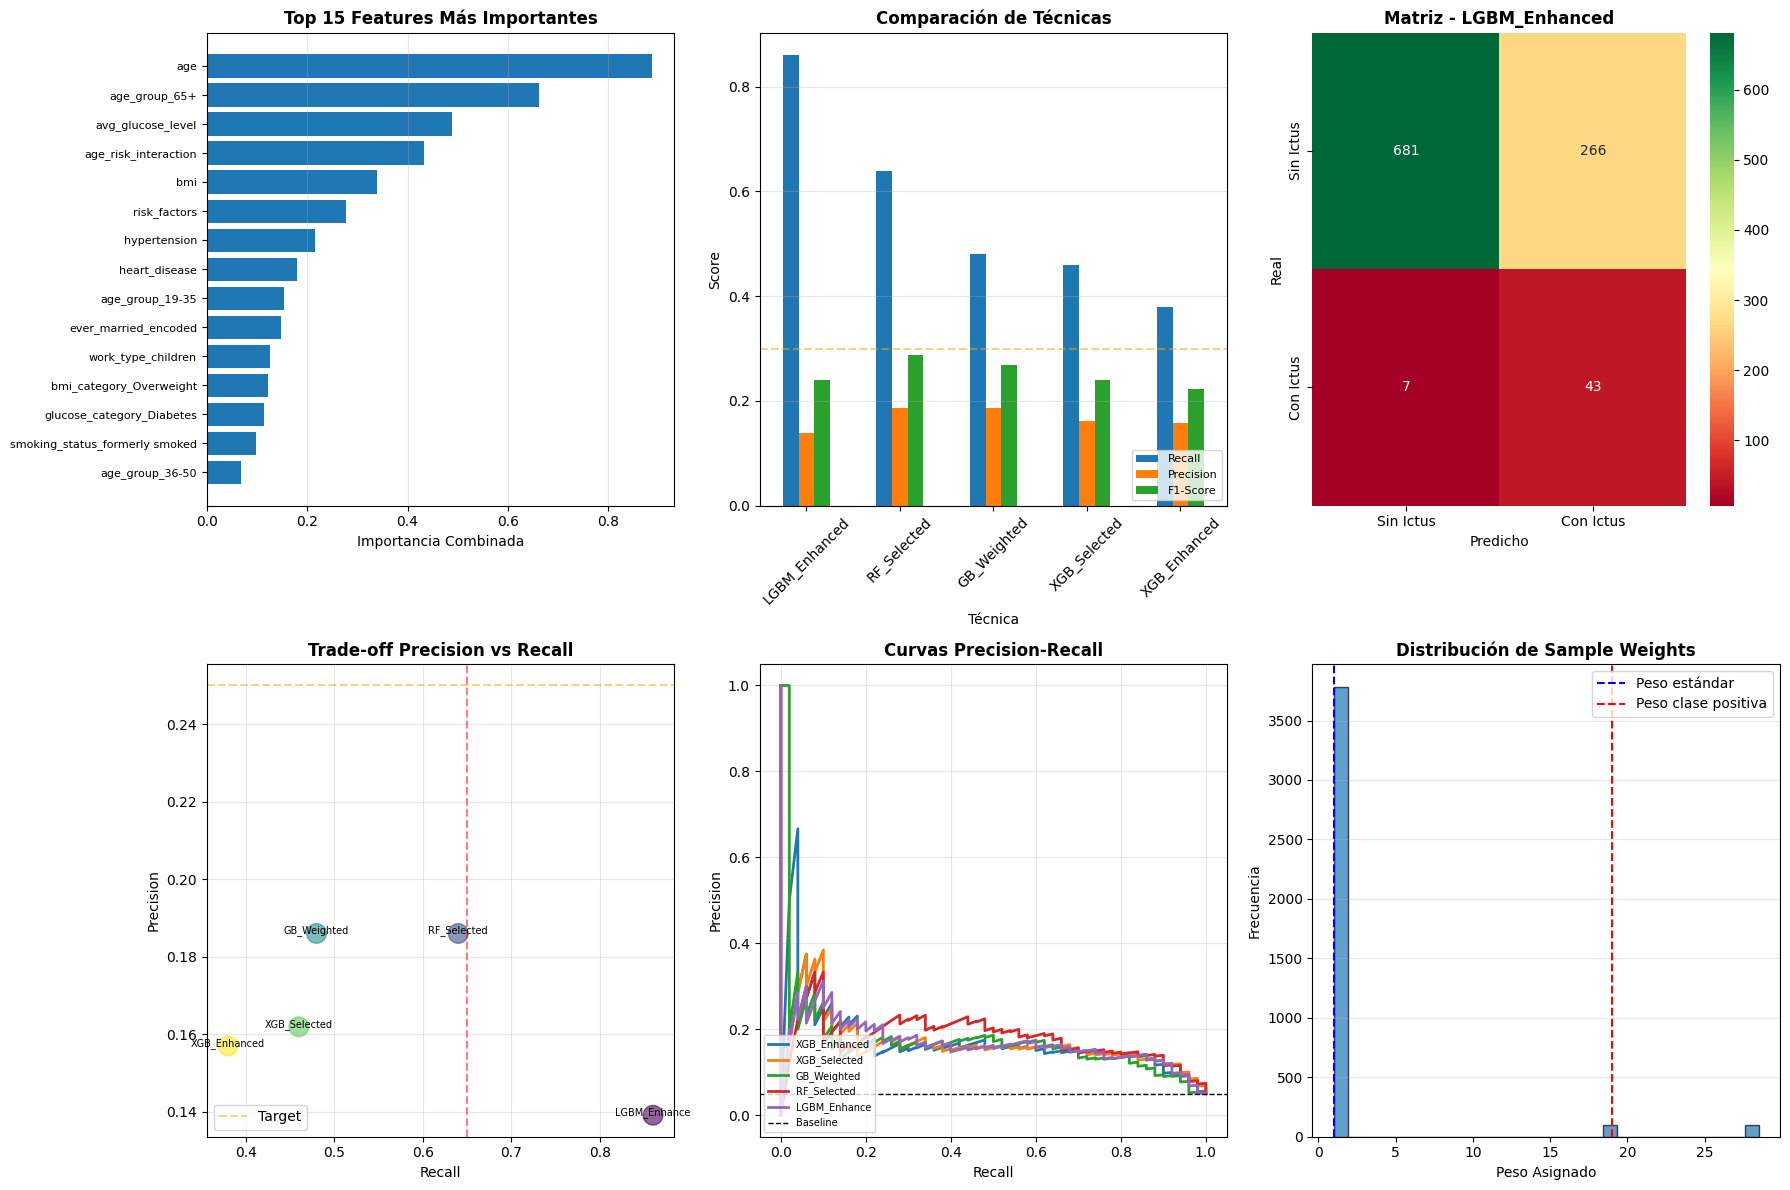

In [9]:
# ===========================================
# 8. VISUALIZACIONES
# ===========================================
print("\n" + "="*60)
print("📈 8. GENERANDO VISUALIZACIONES")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Gráfico 1: Feature Importance
top_15 = df_importance.head(15)
axes[0, 0].barh(range(len(top_15)), top_15['combined_score'].values)
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels(top_15['feature'].values, fontsize=8)
axes[0, 0].set_xlabel('Importancia Combinada')
axes[0, 0].set_title('Top 15 Features Más Importantes', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(alpha=0.3, axis='x')

# Gráfico 2: Comparación de modelos
df_comp_plot = df_comp[['Técnica', 'Recall', 'Precision', 'F1-Score']].copy()
df_comp_plot.set_index('Técnica').plot(kind='bar', ax=axes[0, 1], rot=45)
axes[0, 1].set_title('Comparación de Técnicas', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend(loc='lower right', fontsize=8)
axes[0, 1].grid(alpha=0.3, axis='y')
axes[0, 1].axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Target Precision')

# Gráfico 3: Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0, 2],
            xticklabels=['Sin Ictus', 'Con Ictus'],
            yticklabels=['Sin Ictus', 'Con Ictus'])
axes[0, 2].set_title(f'Matriz - {best_model_name}', fontweight='bold')
axes[0, 2].set_ylabel('Real')
axes[0, 2].set_xlabel('Predicho')

# Gráfico 4: Precision vs Recall scatter
axes[1, 0].scatter(df_comp['Recall'], df_comp['Precision'], s=200, alpha=0.6, 
                   c=range(len(df_comp)), cmap='viridis')
for i, row in df_comp.iterrows():
    axes[1, 0].annotate(row['Técnica'][:12], (row['Recall'], row['Precision']), 
                       fontsize=7, ha='center')
axes[1, 0].axhline(y=0.25, color='orange', linestyle='--', alpha=0.5, label='Target')
axes[1, 0].axvline(x=0.65, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Trade-off Precision vs Recall', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Gráfico 5: Curva Precision-Recall
from sklearn.metrics import precision_recall_curve
for name in list(resultados.keys()):
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, resultados[name]['y_pred_proba'])
    axes[1, 1].plot(rec_curve, prec_curve, label=name[:12], linewidth=2)

axes[1, 1].axhline(y=(y_test==1).sum()/len(y_test), color='k', linestyle='--', 
                  label=f'Baseline', linewidth=1)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Curvas Precision-Recall', fontweight='bold')
axes[1, 1].legend(fontsize=7, loc='lower left')
axes[1, 1].grid(alpha=0.3)

# Gráfico 6: Distribución sample weights
axes[1, 2].hist(sample_weights, bins=30, edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Peso Asignado')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].set_title('Distribución de Sample Weights', fontweight='bold')
axes[1, 2].axvline(x=1.0, color='blue', linestyle='--', label='Peso estándar')
axes[1, 2].axvline(x=19.0, color='red', linestyle='--', label='Peso clase positiva')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tecnicas_avanzadas_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualizaciones guardadas")
plt.show()

In [10]:
# ===========================================
# 9. GUARDAR MODELO
# ===========================================
print("\n" + "="*60)
print("💾 9. GUARDADO DEL MODELO FINAL")
print("="*60)

model_package = {
    'model': best_model_info['model'],
    'model_name': best_model_name,
    'scaler': scaler,
    'feature_names': feature_names,
    'top_features': top_features,
    'top_indices': top_indices,
    'poly_transformer': poly if 'Enhanced' in best_model_name else None,
    'top_5_indices': top_5_indices if 'Enhanced' in best_model_name else None,
    'metrics': {
        'recall': best_model_info['recall'],
        'precision': best_model_info['precision'],
        'f1': best_model_info['f1'],
        'auc_pr': best_model_info['auc_pr'],
        'vpp': vpp,
        'vpn': vpn
    },
    'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)},
    'feature_importance': df_importance
}

with open('modelo_tecnicas_avanzadas.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Modelo guardado: modelo_tecnicas_avanzadas.pkl")


💾 9. GUARDADO DEL MODELO FINAL
✅ Modelo guardado: modelo_tecnicas_avanzadas.pkl


In [11]:
# ===========================================
# 10. RESUMEN EJECUTIVO
# ===========================================
print("\n" + "="*60)
print("📋 10. RESUMEN EJECUTIVO")
print("="*60)

print(f"""
🏆 MEJOR TÉCNICA: {best_model_name}

📊 RESULTADOS FINALES:
   • Recall:     {best_model_info['recall']:.4f} ({best_model_info['recall']*100:.1f}%)
   • Precision:  {best_model_info['precision']:.4f} ({best_model_info['precision']*100:.1f}%) ⭐
   • F1-Score:   {best_model_info['f1']:.4f}
   • AUC-PR:     {best_model_info['auc_pr']:.4f}
   • VPP:        {vpp:.4f} ({vpp*100:.1f}%)
   
💡 TÉCNICAS APLICADAS:
   1. ✅ Selección de features (de {len(feature_names)} a {top_k})
   2. ✅ Interacciones polinomiales entre top features
   3. ✅ Sample weights personalizados
   4. ✅ Énfasis en casos difíciles (frontera de decisión)
   5. ✅ Sin SMOTE (evitar datos sintéticos excesivos)

⚕️ INTERPRETACIÓN MÉDICA:
   • De 100 pacientes CON ictus → Detectamos {int(sensibilidad*100)}
   • Si test POSITIVO → {vpp*100:.1f}% probabilidad real de ictus
   • Por cada ictus real → {fp/max(tp,1):.1f} falsos positivos

{"✅ MEJORA SIGNIFICATIVA:" if best_model_

_IncompleteInputError: incomplete input (972243643.py, line 30)